In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [2]:
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.8], '
        select * from bdbbva.usuario
        limit 10
    ')

    """
df_vicidial=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_vicidial.show()

+-------+--------+-----------+-----------+-----------+---------+---------+------+-------+-------+------+---------+--------+
|tCodigo|tNombres|tApePaterno|tApeMaterno|     tLogin|tPassword|tOperario|tNivel|tCorreo|lEstado|tGrupo|tProyecto|    tDni|
+-------+--------+-----------+-----------+-----------+---------+---------+------+-------+-------+------+---------+--------+
|      1|FERNANDO|  GUTIERREZ|  VELASQUEZ| FGUTIERREZ|    12345|        1|     0|  11111|      1|     1|     NULL|42021402|
|      4|FERNANDO| BUSTAMANTE|      ROJAS|FBUSTAMANTE|LEN0891.1|         |     0|       |      1|  NULL|     NULL|47221881|
|      5|   diana|     marcos|           |    dmarcos|    12345|         |     2|       |      0|  NULL|       31|   12345|
|      6|    Ana |   JUNCHAYA|     ZARATE|  AJUNCHAYA| 21425921|         |     2|       |      1|  NULL|     NULL|21425921|
|      7|  CARLOS|    GUEVARA|  SAMANAMUD|   CGUEVARA| 42563503|         |     3|       |      1|  NULL|     NULL|42563503|
|      8

In [2]:
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.8], '
        SELECT DISTINCT
            a.tDocumento AS CODDOC,
            DATE(a.fFechaGrabacion) AS FECHA,
            DATE_FORMAT(a.fFechaGrabacion, ''%m'') AS MES_DURACION_BASE,
            CONCAT(c.tApePaterno,'''' '''',c.tApeMaterno,'''' '''',c.tNombres) as EJECUTIVO,
            RIGHT(''00000''+c.tDni,8) as DNI_EJECUTIVO,
            b.tCuotasF7 AS cuota,
            ''Cenco_Prest'' AS CAMPANA,
            CAST(NULLIF(b.tMontoF7, '''') AS DECIMAL(18,2)) AS MONTO,
            b.tTipoCampanaF7 AS Producto
        FROM bdsae2.tb_clientes a
        INNER JOIN bdsae2.tb_solicitud b
            ON a.tRegistro = b.tRegistro
        INNER JOIN bdbbva.usuario c
            ON a.tUsuario = c.tCodigo
        WHERE DATE(a.fFechaGrabacion) >= ''2026-08-01''
        and DATE(a.fFechaGrabacion) <= ''2026-08-08''
    ')

    """
df_ventas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_ventas.show(3)

+--------+----------+-----------------+--------------------+-------------+-----+-----------+--------+--------+
|  CODDOC|     FECHA|MES_DURACION_BASE|           EJECUTIVO|DNI_EJECUTIVO|cuota|    CAMPANA|   MONTO|Producto|
+--------+----------+-----------------+--------------------+-------------+-----+-----------+--------+--------+
|09562296|2026-08-01|               08|CORTEZMARAVIGIOVANNA|     40415122|   12|Cenco_Prest|10000.00|     SAE|
|09568102|2026-08-01|               08|PINTOSARAVIAJANET...|     10372619|   12|Cenco_Prest|14800.00|     SAE|
|08654688|2026-08-01|               08|NAVARROCASTILLOKE...|     73008715|   12|Cenco_Prest| 2000.00|     SAE|
+--------+----------+-----------------+--------------------+-------------+-----+-----------+--------+--------+
only showing top 3 rows


In [ ]:
# query = """
#     select DNI as CODDOC,CAMPANA,SubCampana,Producto,FORMAT(FECHA, 'MM') as  MES_DURACION_BASE,MONTO from SAMANTHA.dbo.Ventas_Target
#     where FECHA>='2026-04-01'
#     and FECHA<'2026-05-01'
#     and CAMPANA='Cenco_Prest'
#     and Producto='cd'
#     """
# df_ventas = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

In [26]:
# query = """
#     select DNI as CODDOC,CAMPANA,SubCampana,Producto,FORMAT(FECHA, 'MM') as  MES_DURACION_BASE,MONTO from SAMANTHA.dbo.Ventas_Target
#     where FECHA>='2026-01-01'
#     and CAMPANA='Cenco_Prest'
#     """
# df_ventas = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
query = """
  select CODDOC,FECHA_ENVIO,LINEA_DINERS,PERFIL, prioridad,RECORRIDO,CET,CNTVTAS,ejecutivo as ejecutivo_1,
  RIGHT(CONCAT('00',MES_DURACION_BASE),2) as MES_DURACION_BASE,CNT_LLAMADAS
  from maeba.ADM_OBJ_TG.tGestionMesCencoPP
  where FECHA_ENVIO>='2026-08-01'
    """
df_ene_jun = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

df_ene_jun=df_ene_jun.join(df_ventas,['CODDOC','MES_DURACION_BASE'],'left')


In [27]:
window_spec = Window.partitionBy("CODDOC",'MES_DURACION_BASE').orderBy(F.col("FECHA_ENVIO").desc_nulls_last(),F.col("FECHA").desc_nulls_last())
df_ene_jun = df_ene_jun.withColumn("ref_01", row_number().over(window_spec))
df_ene_jun = df_ene_jun.filter(F.col("ref_01") == 1).drop('ref_01')


In [28]:
df_ene_jun = df_ene_jun.withColumn(
    "taken",
    F.when(
        F.col("LINEA_DINERS") > 0,
        F.col("MONTO") / F.col("LINEA_DINERS")
    ).otherwise(None)
)

In [7]:
print([row['cuota' ] for row in df_ene_jun.select('cuota').distinct().collect()])
print([row['LINEA_DINERS' ] for row in df_ene_jun.select('LINEA_DINERS').distinct().collect()])
print([row['PERFIL' ] for row in df_ene_jun.select('PERFIL').distinct().collect()])
print([row['RECORRIDO' ] for row in df_ene_jun.select('RECORRIDO').distinct().collect()])
print([row['CAMPANA' ] for row in df_ene_jun.select('CAMPANA').distinct().collect()])
print([row['MONTO' ] for row in df_ene_jun.select('MONTO').distinct().collect()])
print([row['prioridad' ] for row in df_ene_jun.select('prioridad').distinct().collect()])
print([row['CET' ] for row in df_ene_jun.select('CET').distinct().collect()])

print([row['CNTVTAS' ] for row in df_ene_jun.select('CNTVTAS').distinct().collect()])


['15', '30', '16', '18', '6', '60', '25', '48', '24', '20', '36', '12', '40', '50', None]
[Decimal('3500.00'), Decimal('37900.00'), Decimal('7600.00'), Decimal('20600.00'), Decimal('37000.00'), Decimal('3337.00'), Decimal('9765.00'), Decimal('11999.00'), Decimal('1130.00'), Decimal('32100.00'), Decimal('4342.00'), Decimal('1620.00'), Decimal('4576.00'), Decimal('1228.00'), Decimal('3900.00'), Decimal('740.00'), Decimal('6320.00'), Decimal('20500.00'), Decimal('4439.00'), Decimal('26300.00'), Decimal('1299.00'), Decimal('3438.00'), Decimal('31700.00'), Decimal('2160.00'), Decimal('12600.00'), Decimal('1421.00'), Decimal('3436.00'), Decimal('26100.00'), Decimal('850.00'), Decimal('11990.00'), Decimal('1848.00'), Decimal('12816.00'), Decimal('2480.00'), Decimal('2730.00'), Decimal('8900.00'), Decimal('22200.00'), Decimal('28300.00'), Decimal('29000.00'), Decimal('8820.00'), Decimal('11300.00'), Decimal('39600.00'), Decimal('1554.00'), Decimal('4480.00'), Decimal('29900.00'), Decimal('803.

In [30]:
from pyspark.sql import functions as F

df_resumen = (
    df_ene_jun
    .groupBy(
        "MES_DURACION_BASE",
        "PERFIL",
        "prioridad",
        "ejecutivo_1",
    )
    .agg(
        F.count("CODDOC").alias("base"),
        F.sum("LINEA_DINERS").alias("oferta"),
        F.sum("RECORRIDO").alias("recorrido"),
        F.sum("CET").alias("cet"),
        F.sum("CNT_LLAMADAS").alias("q_llam"),
        F.sum("CNTVTAS").alias("ventas"),
        F.sum("MONTO").alias("toma"),
        F.avg("cuota").alias("plazo"),
        F.avg("taken").alias("taken")
    )
)

# df_resumen.show()

In [8]:
from pyspark.sql import functions as F

df_resumen_mes = (
    df_ene_jun
    .groupBy("MES_DURACION_BASE")
    .agg(
        F.sum("LINEA_DINERS").alias("oferta")
    )
    .orderBy(F.col("MES_DURACION_BASE").cast("int"))
)

df_resumen_mes.show()

+-----------------+------------+
|MES_DURACION_BASE|      oferta|
+-----------------+------------+
|               06|817375013.00|
|               07|611703300.00|
+-----------------+------------+



In [31]:
df_list_filtrada = df_resumen.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'resumen_cenco_202608_1.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [6]:
df_list_filtrada = df_ventas.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'cenco_202607.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

### armar lista sae / sar

In [ ]:
Monto proyectado :=
VAR FechaMaxima =
    CALCULATE(
        MAX(Tabla1[FECHA]);
        ALL(Tabla1)
    )

VAR MontoActual =
    [Monto mes actual]

VAR DiasTranscurridos =
    DAY(FechaMaxima)

VAR DiasDelMes =
    DAY(EOMONTH(FechaMaxima;0))

RETURN
DIVIDE(
    MontoActual;
    DiasTranscurridos;
    0
)
* DiasDelMes


In [44]:


query = """
  SELECT * FROM CRONOX.dbo.borrar_prestamo_cencosud
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_list_cencosud = df_list_cencosud.withColumn(
    'linea_sae',
    col('linea_sae').cast('int')
)



print(df_list_cencosud.count())
print(df_list_cencosud.columns)

92054
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro', 'fec_pago', 'fecha_ult_atm', 'monto_ant', 'fecha_ult_comp', 'monto_desembolsar', 'rng_saldo_tc_entre_linea_total_tc', 'disp_retiro_efect_', 'mejora_tasa', 'linea_sae', 'pct_sae', 'entidad1', 'deuda1', 'entidad2', 'deuda2', 'entidad3', 'deuda3', 'edad', 'frescura_target', 'flg_mejora', 'propension', 'tipdoc', 'fecha_envio', 'seg_monto', 'seg_tea', 'seg_edad', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_de

In [22]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()

25600

In [ ]:
marca=[' N ', ' Y ', 'Y', 'N']


In [26]:
# mejor_tipi=['VOLVER A LLAMAR - call',]
marca=['  ', ' Y ', 'Y',]

mejor_tipi=[
    'LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'VOLVER A LLAMAR',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'SIN DESCRIPCION',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'VOLVER A LLAMAR - call',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'NUMERO DESCONECTADO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'TELEFONO FUERA DE SERVICIO / NO EXISTE',
 'DESEA IR A AGENCIA',
 'AGENTE NO DISPONIBLE (AUTO)',
 ]
propension=['MEDIO', 'ALTO']


# df_filtrado = df_list_cencosud.filter(
#     # (F.col('title') == 'sae') &  
#     ((F.col('tipo_telf') == 'BBDD CEL01')&(F.length(F.col('phone_number')) == 9)) &
#     ((F.col('mejor_descripcion_cli').isin(mejor_tipi)) | (F.col('mejor_descripcion_cli').isNull())) &
#     ((F.col('mejor_descripcion_telf').isin(mejor_tipi)) | (F.col('mejor_CODIGO_telf').isNull()))&
#     ((F.col('fecha_llamada')<'2026-04-17') | (F.col('fecha_llamada').isNull())) &
#     # (F.col('linea_sae')>=7000)
    
# ).orderBy(col('linea_sae').desc())

# print(df_filtrado.count())

In [14]:
df_filtrado = df_parte_3.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments',
)
df_dni = df_filtrado.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'df_parte_3.xlsx')

df_dni.to_excel(ruta_archivo, index=False)


In [10]:

df_list_cencosud.groupBy('title') \
    .count() \
    .orderBy('title') \
    .show(30, truncate=False)

+-----+-----+
|title|count|
+-----+-----+
|NULL |89917|
+-----+-----+



In [35]:
print([row['mejor_descripcion_telf' ] for row in df_list_cencosud.select('mejor_descripcion_telf').distinct().collect()])
# mejor_estado_tipi_cli=['CONTVO', 'NCTO', 'CONTACTO EFECTIVO', 'ONADO',]


['VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', None]


In [70]:
df_list_filtrada = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'rec.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [69]:
# mejor_tipi=['VOLVER A LLAMAR - call',]

mejor_descripcion_telf=[
    # 'VOLVER A LLAMAR',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
]


df_filtrado = df_list_cencosud.filter(
    ( 
        (F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO')) | 
        (F.col('mejor_estado_tipi_cli').isNull())
    ) &     
    ( 
        (F.col('mejor_descripcion_cli').isin(mejor_descripcion_telf)) | 
        (F.col('mejor_descripcion_cli').isNull())
    ) &    
    ( 
        (F.col('mejor_descripcion_telf').isin(mejor_descripcion_telf)) | 
        (F.col('mejor_descripcion_telf').isNull())
    ) &
    (
        (F.col('tipo_telf')=='CEL01')|
        (F.col('tipo_telf')=='CEL02')|
        (F.col('tipo_telf')=='CEL03')
    )&
    # ((F.col('tipo_telf') == 'BBDD CEL01')&(F.length(F.col('phone_number')) == 9)) &
    # (F.col('mejor_estado_tipi_cli') != 'CONTACTO EFECTIVO') &  
    # (F.col('propension').isin('ALTO','MEDIO','')) &  
    # (F.col('linea_sae')>=10000) &  
        ((F.col('fecha_llamada')<'2026-06-06') | (F.col('fecha_llamada').isNull())) &

    # (
        
    #     (
    #         (F.col('fecha_llamada')=='2026-05-16') 
            #  (F.col('q_intentos_telf').isNull())&
    #      )
    # )

    (F.col('title') == 'REC') &  
    (F.col('retiro').isin('no_aplica')) 
    
).orderBy(col('linea_sae').desc())

df_filtrado=df_filtrado.dropDuplicates(['vendor_lead_code'])
print(df_filtrado.count())

917


In [34]:
df_list_cencosud.filter(
    F.col('title') == 'sae'
).dropDuplicates(
    ['vendor_lead_code']
).count()

27501

In [11]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('propension',"entidad1",'seg_edad').orderBy(F.rand())

df_split = df_filtrado.withColumn("grupo_split", F.ntile(3).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")
# df_parte_5 = df_split.filter(F.col("grupo_split") == 5).drop("grupo_split")
# df_parte_6 = df_split.filter(F.col("grupo_split") == 6).drop("grupo_split")
# df_parte_7 = df_split.filter(F.col("grupo_split") == 7).drop("grupo_split")

print(
    df_parte_1.count(),
    df_parte_2.count(),
    df_parte_3.count()
    # df_parte_4.count(),
    # df_parte_5.count(),
    # df_parte_6.count(),
    # df_parte_7.count()
)

4367 4363 4359


In [63]:

df_list_cencosud.groupBy('mejor_descripcion_cli') \
    .count() \
    .orderBy('mejor_descripcion_cli') \
    .show(30, truncate=False)

+-------------------------------------------------+-----+
|mejor_descripcion_cli                            |count|
+-------------------------------------------------+-----+
|NULL                                             |63030|
|AGENTE NO DISPONIBLE (AUTO)                      |521  |
|AUTODIAL NO RESPONDE (AUTO)                      |2071 |
|CLIENTE ACEPTA PRODUCTO                          |38   |
|CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA          |1717 |
|CLIENTE DESEA OTRO PRODUCTO                      |5    |
|CLIENTE FALLECIO                                 |4    |
|DESEA IR A AGENCIA                               |22   |
|EN LLAMADA                                       |2    |
|LLAMADA ELIMINADA POR ERROR EN RED (AUTO)        |88   |
|MENSAJE EN CASILLA DE VOZ (AUTO)                 |13549|
|NO DESEA –NO ESPECIFICA MOTIVO                   |3325 |
|NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)|1528 |
|NO UTILIZA (TARJETAS - PRESTAMOS)                |6    |
|NO VOLVER A L

In [42]:
query = """
  SELECT * FROM DANTALION.dbo.tNumeroCenco_Sae
    """
df_num = obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [45]:
df_num.dropDuplicates(['CODDOC']).count()

25600

In [19]:
df_filtrado.dropDuplicates(['vendor_lead_code']) \
    .groupBy("propension") \
    .count() \
    .orderBy("propension") \
    .show()

+----------+-----+
|propension|count|
+----------+-----+
|      ALTO|  437|
|      BAJO| 1134|
|     MEDIO| 2200|
+----------+-----+



In [11]:
df_filtrado.groupBy("propension") \
    .count() \
    .orderBy("propension") \
    .show()

+----------+-----+
|propension|count|
+----------+-----+
|      ALTO|  808|
|     MEDIO| 2475|
+----------+-----+



In [ ]:
df_filtrado

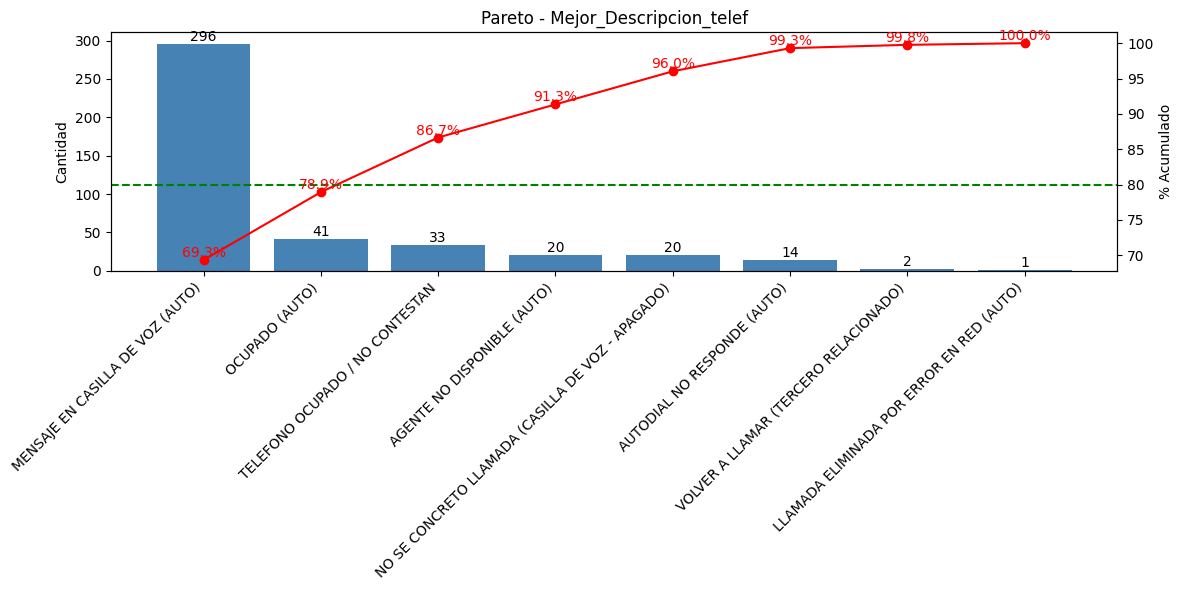

In [96]:
tipificaicon_telf="mejor15_descripcion_telf"
pareto_mejor_descripcion(df_dni,tipificaicon_telf)
exportar_lista(df_filtrado,'SAR_202604021135.xlsx','linea_sae')

In [9]:
cantidad_leads= df_filtrado.count()

In [10]:
info_list=f"""
Se tienen {cantidad_leads} leads
maximo de intentos por num telef: 20
montos menores a 9k
propension ALTO, MEDIO
"""

print(info_list)


Se tienen 7199 leads
maximo de intentos por num telef: 20
montos menores a 9k
propension ALTO, MEDIO



In [127]:
exportar_lista(df_filtrado,'sae_202603281246.xlsx','linea_sae')

In [27]:
print([row['tipo_telf' ] for row in df_list_cencosud.select('tipo_telf').distinct().collect()])


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [85]:
import os

ruta_archivo = os.path.join(ruta_csv, 'sae_202604021110.xlsx')

df_dni.to_excel(ruta_archivo, index=False)
df_dni.count()

vendor_lead_code            2804
phone_number                2804
title                       2804
first_name                  2804
last_name                   2804
address1                    2804
address2                    2804
address3                    2804
city                        2804
province                    2804
email                       2804
security_phrase             2804
comments                    2804
mejor15_descripcion_telf       0
dtype: int64

In [32]:
df_dni.count()


vendor_lead_code            59805
phone_number                59805
title                       59805
first_name                  59805
last_name                   59805
address1                    59805
address2                    59802
address3                    59805
city                        59791
province                    59791
email                       59805
security_phrase             59805
comments                    59805
mejor15_descripcion_telf        1
dtype: int64

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


### armar lista negocios

442509
['vendor_lead_code', 'phone_number', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'MARCA', 'FECHA_ENVIO', 'region', 'prioridada', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejo

13750

66629


In [78]:
print(df_list.columns)

['vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'MARCA', 'FECHA_ENVIO', 'region', 'prioridada', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_tel

In [81]:
df_dni.count()

vendor_lead_code    13275
phone_number        13275
first_name          13275
last_name           13275
address1            13275
address3            13275
city                13275
province            13275
email               13275
comments            13275
dtype: int64

In [73]:
df_prueba.show()

+------------+---------+
|NUMDOCUMENTO| CELULAR1|
+------------+---------+
|     2545316|984407528|
|    44912920|964716621|
|    42029996|964710403|
|    17412355|958461912|
|    43549652|961031439|
|    23710647|964610982|
|    75803816|982526275|
|    41548323|966246307|
|    71857580|979020599|
|    47184200|917299647|
|    48740761|931822039|
|    46813921|969155244|
|    48668673|976370080|
|    70804874|969248488|
|     2438720|958156027|
|    19988564|954474453|
|    20692636|998667999|
|     9259572|954192733|
|    19867221|996805672|
|     1297419|954208538|
+------------+---------+
only showing top 20 rows


In [166]:
df_list=df_list.join(df_list,['vendor_lead_code','phone_number'],'leftanti')

In [167]:
df_list.count()

0

In [14]:
mejor_tipi_cet=['NO QUIERE', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'MENSAJES CON TERCEROS - HIJOS', 'TELEFONO APAGADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'MENSAJES CON TERCEROS - OTROS', 'CLIENTE DE VIAJE', 'TONO OCUPADO', 'DESEA MAS MONTO']


In [36]:
info_list=f"""
Se tienen {cantidad_leads} leads
Zonas : {zona_list}
cet: {mejor_tipi_cet}
{tip_prioridad_list}
{email_list}
"""

print(info_list)


Se tienen 0 leads
Zonas : [1]
cet: ['NO QUIERE', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'MENSAJES CON TERCEROS - HIJOS', 'TELEFONO APAGADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'MENSAJES CON TERCEROS - OTROS', 'CLIENTE DE VIAJE', 'TONO OCUPADO', 'DESEA MAS MONTO']
['PRF', 'ELT']
['LOS OLIVOS', 'AYACUCHO', 'COMAS', 'JULIACA', 'ATE', 'VILLA EL SALVADOR', 'SJL', 'JUNIN', 'AREQUIPA', 'LAMBAYEQUE', 'HUANUCO', 'PIURA', 'CAJAMARCA', 'TACNA', 'SULLANA', 'SJM', 'TRUJILLO', None]



In [27]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number_02', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [28]:

import os

ruta_archivo = os.path.join(ruta_csv, 'negocio_202603271247.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]


## inventario

In [ ]:
fecha_ref = '2026-04-01'

campana_name_1='SAE'
campana_name_2='SAR'
campana_name_3='AGENDA'
venta_campana='Cenco_Prest'
tb_tipologia='tTipologia_Cencosud_PPFF'
dni_tnumero='CODDOC'
cod_letra='R'
tb_tnumero='tNumeroCenco_Sae'

query = f"""
SELECT dni as vendor_lead_code,
phone_number,
codigo_paleta,
    DATEDIFF(MONTH, fecha_llamada, cast('{fecha_ref}'as date)) AS n_mes
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE (nombre_campana LIKE '%{campana_name_1}' or nombre_campana LIKE '%{campana_name_2}' or nombre_campana LIKE '%{campana_name_3}')
AND fecha_llamada >= DATEADD(MONTH, -6, cast('{fecha_ref}'as date))
AND fecha_llamada <  cast('{fecha_ref}'as date)
"""
df_llamadas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

query = f"""
    select 
    DNI as vendor_lead_code,1 as venta
    from SAMANTHA.dbo.Ventas_Target
    where campana='{venta_campana}'
    AND cast(fecha as date) >= DATEADD(MONTH, -2, cast('{fecha_ref}'as date))
    AND cast(fecha as date) <  cast('{fecha_ref}'as date)
    """
df_venta= obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

query = f"""
select CODIGO as codigo_paleta,peso,descripcion from ODIN.dbo.{tb_tipologia}
where TIPO='CONTACTO EFECTIVO'
and LEFT(CODIGO,1)='{cod_letra}'
"""
df_tipi = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

df_llamadas=df_llamadas.join(df_venta,['vendor_lead_code'],'leftanti')
df_llamadas=df_llamadas.join(df_tipi,['codigo_paleta'],'inner')

window_spec = Window.partitionBy("vendor_lead_code",'phone_number').orderBy(F.col("n_mes").asc_nulls_last(),F.col("peso"))
df_llamadas = df_llamadas.withColumn("ref_01", row_number().over(window_spec))
df_llamadas = df_llamadas.filter(F.col("ref_01") == 1).drop('ref_01')

query = f"""
select distinct {dni_tnumero} as vendor_lead_code,Telefonos as phone_number, 1 as ref 
from DANTALION.dbo.{tb_tnumero}
"""
df_tnumero=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
df_tnumero.columns
df_tnumero=df_tnumero.join(df_llamadas,['vendor_lead_code', 'phone_number'],'inner')



In [ ]:


df_tnumero=df_tnumero.withColumn('n_lista',when(((col('descripcion')=='SI QUIERE')|(col('descripcion')=='CREDITO CONCRETADO'))&(col('n_mes')==1),1)
                                            .when((col('descripcion').isin(tipis))&(col('n_mes')>1),3)
                                            .when((col('descripcion').isin(tipis))&(col('n_mes')==1),4)
                                            .when((col('descripcion').isin(tipis))&(col('n_mes')==1),4)
                                            .otherwise(0))

overwrite_table_SQL(spark,df_tnumero,'cet_efe_negocios',server_sa,user_sa,pwd_sa,'CRONOX')

In [53]:

fecha_ref = '2026-04-01'

lla_nombre_campana1='SAE'
lla_nombre_campana2='SAR'
lla_nombre_campana3='AGENDA'
venta_campana='Efectiva'
tb_tipologia='tTipologia_Cencosud_PPFF'
dni_tnumero='CODDOC'
cod_letra='BR'
tb_tnumero='tNumeroCenco_Sae'

query = f"""
SELECT dni as vendor_lead_code,
phone_number,
codigo_paleta,
    DATEDIFF(MONTH, fecha_llamada, '{fecha_ref}') AS n_mes
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE (nombre_campana LIKE '%{lla_nombre_campana1}' | nombre_campana LIKE '%{lla_nombre_campana2}' | nombre_campana LIKE '%{lla_nombre_campana3}')
AND fecha_llamada >= DATEADD(MONTH, -6, '{fecha_ref}')
AND fecha_llamada <  '{fecha_ref}'
"""
df_llamadas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

# query = f"""
#     select 
#     DNI as vendor_lead_code,1 as venta
#     from SAMANTHA.dbo.Ventas_Target
#     where campana='{venta_campana}'
#     and cast(fecha as date) between '2026-02-01' and EOMONTH('{fecha_ref}')
#     """
# df_venta= obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)


Py4JJavaError: An error occurred while calling o2451.jdbc.
: com.microsoft.sqlserver.jdbc.SQLServerException: Sintaxis incorrecta cerca de la palabra clave 'LIKE'.
	at com.microsoft.sqlserver.jdbc.SQLServerException.makeFromDatabaseError(SQLServerException.java:278)
	at com.microsoft.sqlserver.jdbc.SQLServerStatement.getNextResult(SQLServerStatement.java:1788)
	at com.microsoft.sqlserver.jdbc.SQLServerPreparedStatement.doExecutePreparedStatement(SQLServerPreparedStatement.java:688)
	at com.microsoft.sqlserver.jdbc.SQLServerPreparedStatement$PrepStmtExecCmd.doExecute(SQLServerPreparedStatement.java:607)
	at com.microsoft.sqlserver.jdbc.TDSCommand.execute(IOBuffer.java:7825)
	at com.microsoft.sqlserver.jdbc.SQLServerConnection.executeCommand(SQLServerConnection.java:4828)
	at com.microsoft.sqlserver.jdbc.SQLServerStatement.executeCommand(SQLServerStatement.java:321)
	at com.microsoft.sqlserver.jdbc.SQLServerStatement.executeStatement(SQLServerStatement.java:253)
	at com.microsof

In [ ]:

query = f"""
select CODIGO as codigo_paleta,peso,descripcion from ODIN.dbo.{tb_tipologia}
where TIPO='CONTACTO EFECTIVO'
and LEFT(CODIGO,1)='{cod_letra}'
"""
df_tipi = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

# df_llamadas=df_llamadas.join(df_venta,['vendor_lead_code'],'leftanti')
df_llamadas=df_llamadas.join(df_tipi,['codigo_paleta'],'inner')

window_spec = Window.partitionBy("vendor_lead_code",'phone_number').orderBy(F.col("n_mes").asc_nulls_last(),F.col("peso"))
df_llamadas = df_llamadas.withColumn("ref_01", row_number().over(window_spec))
df_llamadas = df_llamadas.filter(F.col("ref_01") == 1).drop('ref_01')

query = f"""
select distinct {dni_tnumero} as vendor_lead_code,Telefonos as phone_number, 1 as ref 
from DANTALION.dbo.{tb_tnumero}
"""
df_tnumero=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
df_tnumero.columns
df_tnumero=df_tnumero.join(df_llamadas,['vendor_lead_code', 'phone_number'],'inner')





# historico propension

In [93]:
fecha_mes_base='2026-04-01'
t_maestra=tb_maestra_cenco_ppff
tnum_dni='CODDOC'
prioridad='propension'

query = f"""
SELECT 
vendor_lead_code,
prioridad_hist
FROM (
    SELECT 
        RIGHT(REPLICATE('0',8) + CAST(a.{tnum_dni} AS VARCHAR(20)), 8) as vendor_lead_code,
        b.{prioridad} as prioridad_hist,
        TRY_CONVERT(date, b.fecha_envio) as fecha_envio,
        ROW_NUMBER() OVER (
            PARTITION BY a.{tnum_dni} 
            ORDER BY TRY_CONVERT(date, b.fecha_envio) DESC
        ) as rn
    FROM DANTALION.dbo.{t_maestra} a
    INNER JOIN DANTALION.dbo.{t_maestra} b
        ON a.{tnum_dni} = b.{tnum_dni}
    WHERE b.{prioridad} IS NOT NULL
    AND b.{tnum_dni} IS NOT NULL
    AND TRY_CONVERT(date, b.fecha_envio) IS NOT NULL
    AND TRY_CONVERT(date, b.fecha_envio) >= DATEADD(MONTH, -6, '{fecha_mes_base}')
    AND TRY_CONVERT(date, b.fecha_envio) <'{fecha_mes_base}'
) t
WHERE rn = 1
"""
df_hist=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
overwrite_table_SQL(spark,df_hist,'borrar_pp_cenco_prioridad_hist',server_sa,user_sa,pwd_sa,'CRONOX')
print(df_hist.columns)

['vendor_lead_code', 'prioridad_hist']


In [ ]:

list_tipi=[
    'VOLVER A LLAMAR',
     'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
     'NO UTILIZA (TARJETAS - PRESTAMOS)',
     'OFERTA DE TASA MUY ALTA',
     'OFERTA DE LINEA MUY BAJA',
     'NO DESEA PAGAR MEMBRESIA',
     'NO DESEA –NO ESPECIFICA MOTIVO',
     'CLIENTE ACEPTA PRODUCTO',
     'DESEA IR A AGENCIA',
     'CLIENTE DESEA OTRO PRODUCTO'
]
fecha_mes_base = '2026-04-01'

tipi_cond1='SAE'
tipi_cond2='SAR'
tipi_cond3='AGENDA'
tipi_cod='Codigo'

tipi_resp_cod='R'
tipi_descrip='DESCRIPCION'
tipi_estado='tipo'

tb_tipologia='tTipologia_Cencosud_PPFF'
dni_tnumero='CODDOC'
tb_tnumero='tNumeroCenco_Sae'

query = f"""
SELECT dni as vendor_lead_code,
phone_number,
codigo_paleta,
    DATEDIFF(MONTH, fecha_llamada, '{fecha_mes_base}') AS n_mes
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE dni is not null 
and (nombre_campana LIKE '%{tipi_cond1}' or nombre_campana LIKE '%{tipi_cond2}' or nombre_campana LIKE '%{tipi_cond3}')
AND fecha_llamada >= DATEADD(MONTH, -6, '{fecha_mes_base}')
AND fecha_llamada <  '{fecha_mes_base}'
"""
df_llamadas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

query = f"""
select {tipi_cod} as codigo_paleta,peso,{tipi_descrip} as descripcion from ODIN.dbo.{tb_tipologia}
where {tipi_estado}='CONTACTO EFECTIVO'
and LEFT({tipi_cod},1)='{tipi_resp_cod}'
"""
df_tipi = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

4142612

In [6]:


list_tipi=[
    'VOLVER A LLAMAR',
     'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
     'NO UTILIZA (TARJETAS - PRESTAMOS)',
     'OFERTA DE TASA MUY ALTA',
     'OFERTA DE LINEA MUY BAJA',
     'NO DESEA PAGAR MEMBRESIA',
     'NO DESEA –NO ESPECIFICA MOTIVO',
     'CLIENTE ACEPTA PRODUCTO',
     'DESEA IR A AGENCIA',
     'CLIENTE DESEA OTRO PRODUCTO'
]
df_tipi=df_tipi.filter(col('descripcion').isin(list_tipi))
df_llamadas=df_llamadas.join(df_tipi,['codigo_paleta'],'inner')

window_spec = Window.partitionBy("vendor_lead_code", "phone_number") \
    .orderBy(
        F.col("n_mes").asc_nulls_last(),
        F.col("peso").desc_nulls_last()
    )

df_llamadas = df_llamadas.withColumn("ref_01", row_number().over(window_spec))
df_llamadas = df_llamadas.filter(F.col("ref_01") == 1).drop('ref_01')

query = f"""
select distinct {dni_tnumero} as vendor_lead_code,Telefonos as phone_number 
from DANTALION.dbo.{tb_tnumero}
"""
df_tnumero=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
df_tnumero=df_tnumero.join(df_llamadas,['vendor_lead_code', 'phone_number'],'inner')
overwrite_table_SQL(spark,df_tnumero,'borrar_pp_cenco_cet',server_sa,user_sa,pwd_sa,'CRONOX')

In [5]:
print([row['descripcion' ] for row in df_tipi.select('descripcion').distinct().collect()])


['VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'NO AUTORIZA CONTINUAR CON LA LLAMADA', 'NO DESEA –NO ESPECIFICA MOTIVO', 'CLIENTE ACEPTA PRODUCTO', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO']


In [ ]:
df_tnumero.count()

In [ ]:
fecha_ref = '2026-04-01'

lla_nombre_campana1='SAE'
lla_nombre_campana2='SAR'
lla_nombre_campana3='AGENDA'
venta_campana='Efectiva'
tb_tipologia='tTipologia_Cencosud_PPFF'
dni_tnumero='CODDOC'
cod_letra='BR'
tb_tnumero='tNumeroCenco_Sae'

query = f"""
SELECT dni as vendor_lead_code,
phone_number,
codigo_paleta,
    DATEDIFF(MONTH, fecha_llamada, '{fecha_ref}') AS n_mes
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE (nombre_campana LIKE '%{lla_nombre_campana1}' | nombre_campana LIKE '%{lla_nombre_campana2}' | nombre_campana LIKE '%{lla_nombre_campana3}')
AND fecha_llamada >= DATEADD(MONTH, -6, '{fecha_ref}')
AND fecha_llamada <  '{fecha_ref}'
"""
df_llamadas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)